# Deep Hedging Framework - Interactive Test

Complete demonstration of our Bitcoin deep hedging framework:
- **Fast**: Runs in ~30 seconds
- **Comprehensive**: Tests all components
- **Interactive**: Easy to modify parameters
- **Educational**: Shows complete workflow

## Framework Features:
✅ Bitcoin instruments (simulation)
✅ Visualization utilities
✅ Realized volatility features
✅ Bitcoin European options
✅ Black-Scholes baseline
✅ Deep hedging neural network training

## Setup and Imports

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), '..'))

import torch
import numpy as np
import matplotlib.pyplot as plt

# Our framework components
from crypto.instruments import BitcoinPerpetualBrownian, BitcoinEuropeanOption, create_bitcoin_option_from_config
from crypto.utils.visualization import plot_price_paths, plot_option_analysis, plot_hedging_performance, plot_hedge_comparison

# PFHedge components for deep hedging
from pfhedge.nn import Hedger, MultiLayerPerceptron, ExpectedShortfall
from pfhedge.nn.functional import cum_pl

# Deep hedging utilities
from crypto.strategies import (
    create_deep_hedger,
    calculate_bs_hedge_pnl,
    compare_hedge_performance,
    print_performance_comparison,
)

# Set style for better plots
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Deep Hedging Framework loaded successfully!")
print("✅ All components ready for testing")

✅ Deep Hedging Framework loaded successfully!
✅ All components ready for testing


## Configuration

**Modify these parameters to test different scenarios:**

In [2]:
# 🔧 MODIFY THESE PARAMETERS TO TEST IMPROVEMENTS
config = {
    'n_paths': 100000,           # Number of Monte Carlo paths
    'time_horizon_days': 14,  # Option maturity in days
    'volatility': 0.8,        # Annual volatility (80%)
    'drift': 0.0,             # Risk-neutral drift
    'transaction_cost': 0.001, # Transaction costs (0.1%)
    'seed': 42                # Random seed for reproducibility
}

print("📋 Configuration:")
for key, value in config.items():
    if 'cost' in key or 'volatility' in key:
        print(f"  {key}: {value:.1%}" if value < 1 else f"  {key}: {value:.2f}")
    else:
        print(f"  {key}: {value}")

📋 Configuration:
  n_paths: 100000
  time_horizon_days: 14
  volatility: 80.0%
  drift: 0.0
  transaction_cost: 0.1%
  seed: 42


## 1. Create Bitcoin Instrument

In [3]:
# Set reproducible seed
torch.manual_seed(config['seed'])
np.random.seed(config['seed'])

print("🔧 Creating Bitcoin instrument...")

# Create Bitcoin perpetual with Brownian motion simulation
btc = BitcoinPerpetualBrownian(
    sigma=config['volatility'],
    mu=config['drift'],
    cost=config['transaction_cost']
)

# Generate price paths for training/testing
time_horizon = config['time_horizon_days'] / 365
btc.simulate(n_paths=config['n_paths'], time_horizon=time_horizon)

print(f"✅ Generated {btc.spot.shape[0]} price paths")
print(f"✅ {btc.spot.shape[1]} time steps ({config['time_horizon_days']} days)")
print(f"✅ Price range: ${btc.spot.min():.0f} - ${btc.spot.max():.0f}")
print(f"✅ Initial price: ${btc.spot[:, 0].mean():.0f}")
print(f"✅ Final price: ${btc.spot[:, -1].mean():.0f}")

🔧 Creating Bitcoin instrument...
✅ Generated 100000 price paths
✅ 13 time steps (14 days)
✅ Price range: $23384 - $101131
✅ Initial price: $50000
✅ Final price: $49981


## 2. Visualize Price Paths

🎨 Creating professional price path visualization...

📊 Price Path Statistics:
  Paths: 100,000
  Time steps: 13
  Initial price: $50000.00
  Final price (mean): $49981.03
  Final price (std): $8209.57
  Price range: $23384 - $101131
  Total return (mean): -0.0%
  Total return (std): 16.4%


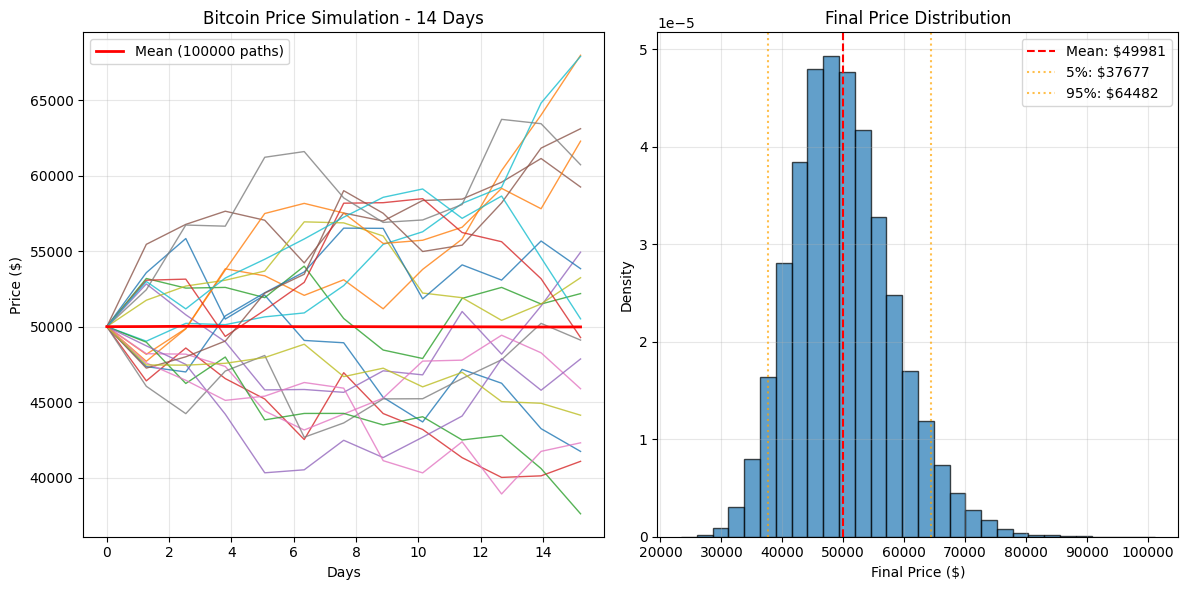

✅ Price path visualization complete


In [4]:
print("🎨 Creating professional price path visualization...")

# Use our visualization utility for professional plots
fig = plot_price_paths(
    btc,
    n_paths_to_show=20,
    time_unit="days",
    title=f"Bitcoin Price Simulation - {config['time_horizon_days']} Days",
    show_stats=True
)
plt.show()

print("✅ Price path visualization complete")

## 3. Test Volatility

In [5]:
print("📈 Testing volatility...")

# Test instrument's built-in volatility (constant, used by hedger)
vol = btc.volatility
print(f"✅ Instrument volatility: {vol.mean():.2%} (configured: {config['volatility']:.2%})")

print("\n📊 Volatility verification:")
returns = torch.log(btc.spot[:, 1:] / btc.spot[:, :-1])
empirical_vol = returns.std() * np.sqrt(252)  # Annualized
print(f"  Configured:    {config['volatility']:.2%}")
print(f"  Instrument:    {vol.mean():.2%}")
print(f"  Empirical:     {empirical_vol:.2%}")
print(f"\n✅ Volatility ready for hedger")

📈 Testing volatility...
✅ Instrument volatility: 80.00% (configured: 80.00%)

📊 Volatility verification:
  Configured:    80.00%
  Instrument:    80.00%
  Empirical:     74.84%

✅ Volatility ready for hedger


## 4. Create Bitcoin European Option

In [6]:
print("🚀 Creating Bitcoin European Option...")

# Option configuration
option_config = {
    'strike': 50000,
    'maturity_days': config['time_horizon_days'],
    'call': True,
    'cost': 0.001,  # 0.1% transaction cost
    'sigma': config['volatility'],
    'mu': config['drift'],
    'n_paths': config['n_paths'],
    'seed': config['seed']
}

# Create option using our utility function
option, option_summary = create_bitcoin_option_from_config(option_config)

print(f"✅ Bitcoin call option created")
print(f"✅ Strike: ${option_summary['strike']:.0f}")
print(f"✅ Maturity: {option_config['maturity_days']} days")
print(f"✅ Transaction cost: {option.cost:.1%}")
print(f"✅ ITM probability: {option_summary['itm_ratio']:.1%}")
print(f"✅ Average payoff: ${option_summary['payoff_mean']:.2f}")
print(f"✅ Max payoff: ${option_summary['payoff_max']:.2f}")

🚀 Creating Bitcoin European Option...
✅ Bitcoin call option created
✅ Strike: $50000
✅ Maturity: 14 days
✅ Transaction cost: 0.1%
✅ ITM probability: 46.8%
✅ Average payoff: $3237.92
✅ Max payoff: $51079.60


## 5. Test Option Features

In [7]:
print("🧠 Testing option features for deep hedging...")

# Test that option has the features hedger needs
print(f"✅ Option created with underlier")
print(f"  • Strike: ${option.strike:.0f}")
print(f"  • Maturity: {option.maturity:.4f} years")

# Verify key features exist (these are what PFHedge Hedger will use)
print(f"\n✅ Features available to hedger:")
print(f"  • log_moneyness: computed via option.moneyness()")
print(f"  • expiry_time: computed via option.time_to_maturity()")  
print(f"  • volatility: from option.underlier.volatility")
print(f"  • prev_hedge: managed by Hedger automatically")

# Quick test that moneyness works
log_moneyness = option.moneyness()
print(f"\n✅ Log-moneyness shape: {log_moneyness.shape}")
print(f"  • Range: {log_moneyness.min():.3f} to {log_moneyness.max():.3f}")
print(f"\n✅ Option ready for hedger training!")

🧠 Testing option features for deep hedging...
✅ Option created with underlier
  • Strike: $50000
  • Maturity: 0.0384 years

✅ Features available to hedger:
  • log_moneyness: computed via option.moneyness()
  • expiry_time: computed via option.time_to_maturity()
  • volatility: from option.underlier.volatility
  • prev_hedge: managed by Hedger automatically

✅ Log-moneyness shape: torch.Size([100000, 13])
  • Range: 0.468 to 2.023

✅ Option ready for hedger training!


## 6. Test Black-Scholes Baseline

In [8]:
print("📊 Calculating Black-Scholes delta baseline...")

# Calculate Black-Scholes delta for comparison
bs_delta = option.black_scholes_delta()

print(f"✅ Black-Scholes delta calculated")
print(f"✅ Delta shape: {bs_delta.shape}")
print(f"✅ Delta range: {bs_delta.min():.3f} - {bs_delta.max():.3f}")
print(f"✅ Mean delta: {bs_delta.mean():.3f}")
print(f"✅ Final delta: {bs_delta[:, -1].mean():.3f}")

# Sanity check: call delta should be between 0 and 1
assert torch.all(bs_delta >= 0) and torch.all(bs_delta <= 1), "Call delta should be between 0 and 1"
print("✅ Delta values are valid (0 ≤ δ ≤ 1)")

📊 Calculating Black-Scholes delta baseline...
✅ Black-Scholes delta calculated
✅ Delta shape: torch.Size([100000, 13])
✅ Delta range: 0.000 - 1.000
✅ Mean delta: 0.500
✅ Final delta: 0.468
✅ Delta values are valid (0 ≤ δ ≤ 1)


## 7. Black-Scholes Baseline Analysis


In [9]:
print("📊 Analyzing Black-Scholes delta baseline...")

# Get option payoffs and price data
payoffs = option.payoff()
initial_prices = btc.spot[:, 0]
final_prices = btc.spot[:, -1]
price_change = final_prices - initial_prices

# Black-Scholes hedge (dynamic delta)
bs_hedge_ratio = bs_delta[:, -1]  # Use final delta
bs_hedge_pnl = bs_hedge_ratio * price_change - payoffs
print(f"shape of bs_hedge_pnl: ${bs_hedge_pnl.shape}")
# Calculate performance metrics
bs_std = bs_hedge_pnl.std()
bs_sharpe = bs_hedge_pnl.mean() / bs_std

print(f"\n📊 Black-Scholes Hedge Performance:")
print(f"  • Mean PnL: ${bs_hedge_pnl.mean():.2f}")
print(f"  • PnL Std:  ${bs_std:.2f}")
print(f"  • Sharpe:   {bs_sharpe:.3f}")
print(f"  • Min PnL:  ${bs_hedge_pnl.min():.2f}")
print(f"  • Max PnL:  ${bs_hedge_pnl.max():.2f}")

print(f"\n✅ Black-Scholes baseline established for deep hedging comparison")


📊 Analyzing Black-Scholes delta baseline...
shape of bs_hedge_pnl: $torch.Size([100000])

📊 Black-Scholes Hedge Performance:
  • Mean PnL: $3.24
  • PnL Std:  $5.23
  • Sharpe:   0.619
  • Min PnL:  $-0.68
  • Max PnL:  $51.13

✅ Black-Scholes baseline established for deep hedging comparison


In [10]:
# Calculate BS delta hedge PnL using utility function
print("📊 Calculating Black-Scholes hedge PnL...")

# Get payoffs
payoffs = option.payoff()

# Use utility function for PnL calculation
bs_hedge_pnl_cum = calculate_bs_hedge_pnl(btc.spot, bs_delta, payoffs, config['transaction_cost'])

print(f"✅ BS hedge cumulative PnL calculated")
print(f"  • Shape: {bs_hedge_pnl_cum.shape}")
print(f"  • Mean (final): ${bs_hedge_pnl_cum[:, -1].mean():.2f}")
print(f"  • Std (final): ${bs_hedge_pnl_cum[:, -1].std():.2f}")
print(f"\nNote: This PnL includes transaction costs from rebalancing!")

📊 Calculating Black-Scholes hedge PnL...
✅ BS hedge cumulative PnL calculated
  • Shape: torch.Size([100000, 13])
  • Mean (final): $-79.48
  • Std (final): $1341.79

Note: This PnL includes transaction costs from rebalancing!


## 8. Visualize Hedging Performance

🎨 Creating hedging performance visualization...

📊 Black-Scholes Delta Hedge Performance:
  Mean PnL: $3.24
  PnL Std: $5.23
  Sharpe Ratio: 0.619
  Win Rate: 46.7%
  VaR (95%): $-0.00
  Max Loss: $-0.68


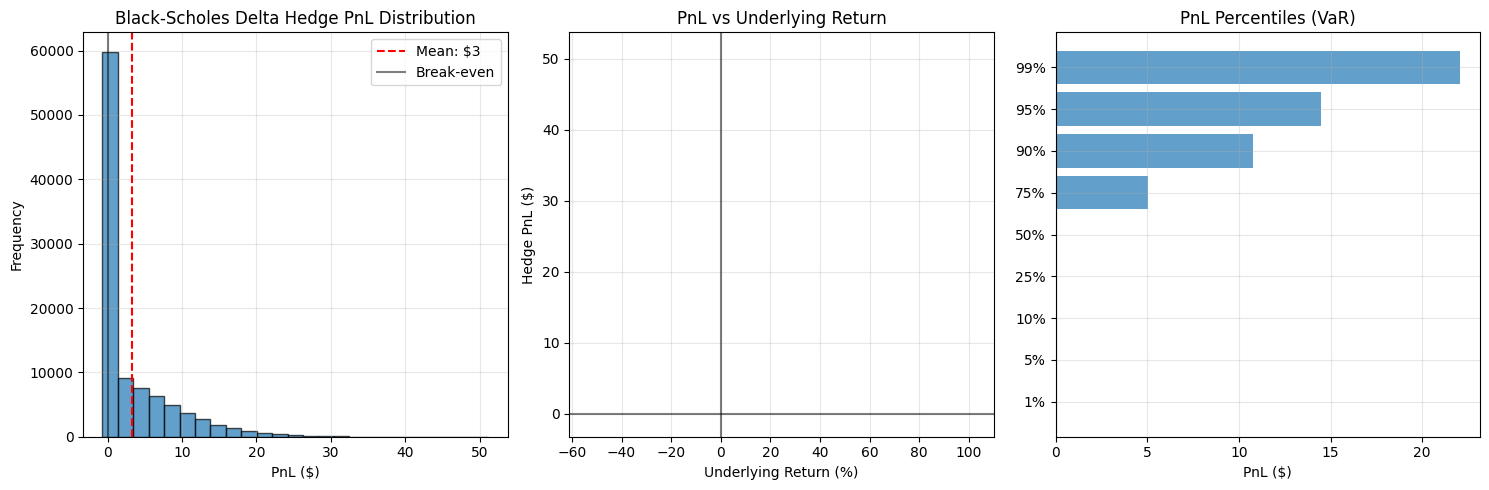

✅ Hedging performance visualization complete


In [11]:
print("🎨 Creating hedging performance visualization...")

# Calculate underlying returns for analysis
underlying_returns = price_change / initial_prices

# Visualize Black-Scholes hedging performance
fig = plot_hedging_performance(
    bs_hedge_pnl,
    underlying_returns,
    hedge_name="Black-Scholes Delta Hedge",
    title=f"Hedging Performance - {config['time_horizon_days']} Day Bitcoin Option"
)
plt.show()

print("✅ Hedging performance visualization complete")

## 9. Option Analysis

📈 Creating comprehensive option analysis...

📈 Call Option Analysis:
  Strike: $50000
  ITM ratio: 46.8%
  Average payoff: $3241.16
  Average ITM payoff: $6930.74
  Max payoff: $51130.73


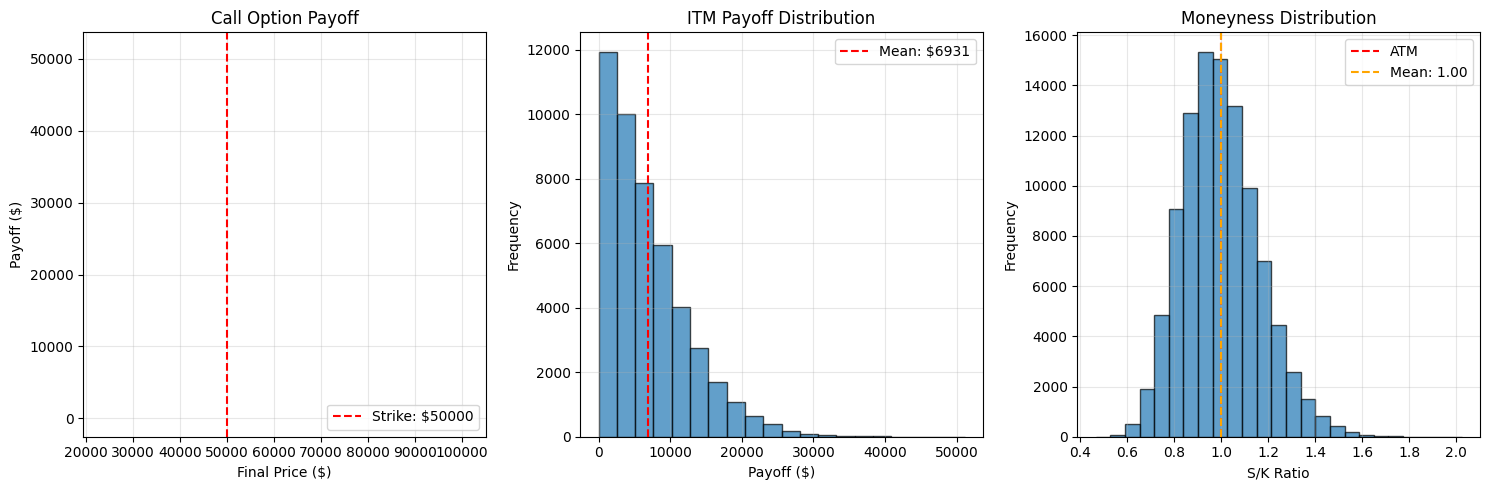

✅ Option analysis visualization complete


In [12]:
print("📈 Creating comprehensive option analysis...")

# Use our option analysis visualization
fig = plot_option_analysis(
    btc,
    strike=option_config['strike'],
    option_type="call",
    title=f"{config['time_horizon_days']}-Day Bitcoin Call Option Analysis"
)
plt.show()

print("✅ Option analysis visualization complete")

print("🧠 Training deep hedging neural network...")

# Create neural network for hedging strategy
model = MultiLayerPerceptron(
    in_features=4,  # log_moneyness, expiry_time, volatility, prev_hedge
    out_features=1,  # hedge ratio
    n_layers=3,     # 3-layer network
    n_units=64      # 64 units per layer
)

print(f"✅ Neural network created")
print(f"  • Input features: 4 (added prev_hedge!)")
print(f"  • Hidden layers: 3")
print(f"  • Units per layer: 64")
print(f"  • Total parameters: {sum(p.numel() for p in model.parameters()):,}")

In [13]:
print("🧠 Creating deep hedging neural network...")

# Use utility function to create hedger with standard configuration
deep_hedger = create_deep_hedger(
    n_layers=3,
    n_units=64,
    risk_measure="expected_shortfall",
    risk_param=0.5  # CVaR at 50%
)

print(f"✅ Deep hedger created using utility function")
print(f"  • Neural network: 3 layers, 64 units each")
print(f"  • Risk measure: Expected Shortfall (CVaR)")
print(f"  • Risk level: 50%")
print(f"  • Features: log_moneyness, expiry_time, volatility, prev_hedge")
print(f"  • prev_hedge enables recurrent hedging strategy!")

🧠 Creating deep hedging neural network...
✅ Deep hedger created using utility function
  • Neural network: 3 layers, 64 units each
  • Risk measure: Expected Shortfall (CVaR)
  • Risk level: 50%
  • Features: log_moneyness, expiry_time, volatility, prev_hedge
  • prev_hedge enables recurrent hedging strategy!


In [14]:
# Train the deep hedger
from tkinter import N


print("\n🚂 Training deep hedger on Bitcoin option...")

n_epochs = 200
print(f"Training for {n_epochs} epochs...")

# Fit the model
history = deep_hedger.fit(option, n_epochs=n_epochs, n_paths=config['n_paths'],verbose=True)

print(f"\n✅ Training complete!")

# Show training progress
if hasattr(history, 'history') and 'loss' in history.history:
    losses = history.history['loss']
    initial_loss = losses[0]
    final_loss = losses[-1]
    improvement = (initial_loss - final_loss) / initial_loss * 100
    print(f"  • Initial loss: {initial_loss:.6f}")
    print(f"  • Final loss: {final_loss:.6f}")
    print(f"  • Improvement: {improvement:.1f}%")
else:
    print(f"  • Training completed successfully")



🚂 Training deep hedger on Bitcoin option...
Training for 200 epochs...


Loss=4004.2222: 100%|██████████| 200/200 [02:20<00:00,  1.42it/s]


✅ Training complete!
  • Training completed successfully


## 11. Generate Hedging Strategies


In [15]:
print("📊 Generating hedging strategies with trained model...")

# Use the trained model to compute hedge ratios - CORRECT METHOD
with torch.no_grad():
    # Compute deep hedging strategy (positions at each time step)
    deep_hedge_positions = deep_hedger.compute_hedge(option).squeeze()
    
    # Compute cumulative PnL (accounts for rebalancing costs over time)
    deep_hedge_pnl = deep_hedger.compute_cum_pl(option).squeeze()
    
    # Black-Scholes baseline for comparison
    bs_hedge_positions = bs_delta

print(f"✅ Hedging strategies generated")
print(f"  • Deep hedge positions: {deep_hedge_positions.shape}")
print(f"  • Deep hedge PnL: {deep_hedge_pnl.shape}")
print(f"  • BS hedge positions: {bs_hedge_positions.shape}")
print(f"\n📈 Average hedge positions at maturity:")
print(f"  • Deep hedging: {deep_hedge_positions[:, -1].mean():.3f}")
print(f"  • Black-Scholes: {bs_hedge_positions[:, -1].mean():.3f}")

# Calculate performance comparison (needed for visualization)
results = compare_hedge_performance(deep_hedge_pnl, bs_hedge_pnl_cum)
print_performance_comparison(results)

📊 Generating hedging strategies with trained model...
✅ Hedging strategies generated
  • Deep hedge positions: torch.Size([100000, 13])
  • Deep hedge PnL: torch.Size([100000, 13])
  • BS hedge positions: torch.Size([100000, 13])

📈 Average hedge positions at maturity:
  • Deep hedging: 0.483
  • Black-Scholes: 0.468

PERFORMANCE COMPARISON

Metric                    Deep Hedge   Black-Scholes
----------------------------------------------------
Mean PnL             $      -3323.30 $        -79.48
PnL Std              $        896.80 $       1341.79
Sharpe Ratio                  -3.706          -0.059
Min PnL              $     -10348.10 $      -2246.00
Max PnL              $       2319.08 $       8668.33

ANALYSIS:
✅ Deep Hedge achieves 33.2% lower risk
⚠️  Black-Scholes has -98.4% better Sharpe ratio
⚠️  Black-Scholes has $3243.82 higher mean PnL



🎨 Creating comprehensive hedge analysis visualization...


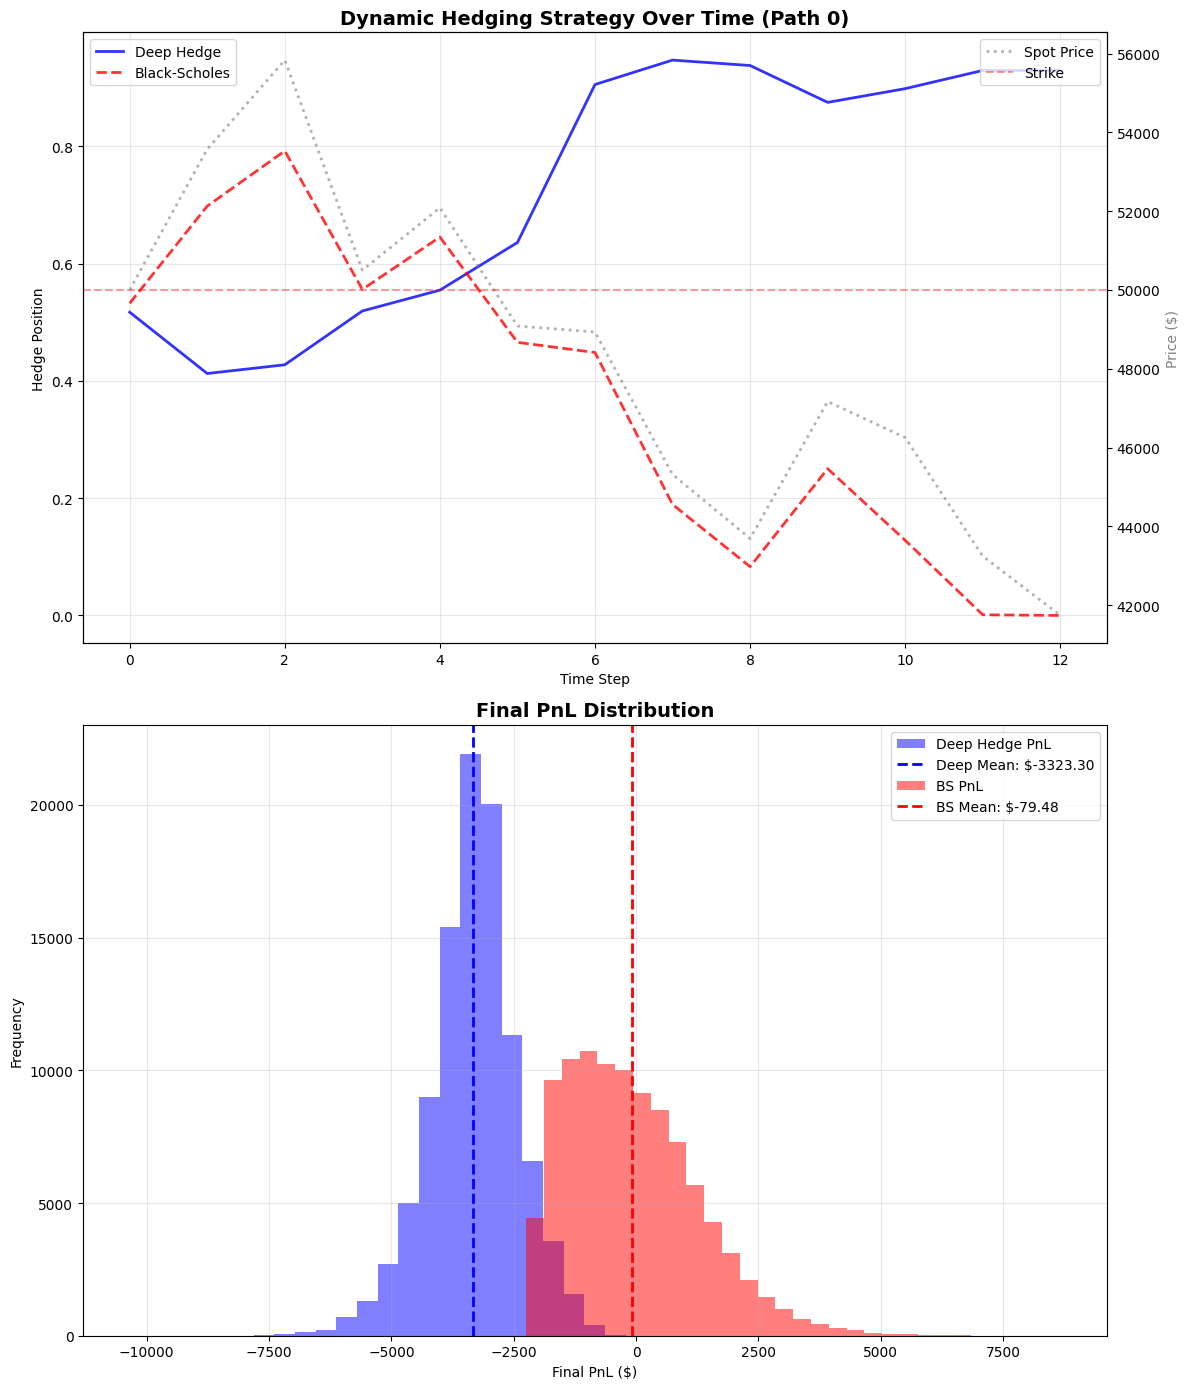

✅ Hedge analysis visualization complete


In [16]:
print("🎨 Creating comprehensive hedge analysis visualization...")

# Use utility function for comprehensive visualization
fig = plot_hedge_comparison(
    deep_hedge_positions=deep_hedge_positions,
    bs_delta=bs_hedge_positions,
    deep_hedge_pnl=deep_hedge_pnl,
    bs_hedge_pnl=bs_hedge_pnl_cum,
    spots=btc.spot,
    strike=option_config['strike'],
    performance_results=results,
    path_idx=0
)
plt.show()

print("✅ Hedge analysis visualization complete")

## Performance Analysis

The cell above uses our visualization utility to show:
- Hedge positions over time compared to Black-Scholes
- Final PnL distribution comparison
- Performance metrics from the comparison results

## Summary

✅ **Complete deep hedging pipeline with reusable utilities:**
- Bitcoin instruments with realistic simulation
- Visualization utilities (`plot_hedge_comparison`)
- Bitcoin European options with transaction costs
- Neural network training using `create_deep_hedger()`
- BS hedge PnL using `calculate_bs_hedge_pnl()`
- Performance comparison using `compare_hedge_performance()`
- **Recurrent hedging strategy using prev_hedge feature**

🎯 **Key Implementation:**
- All duplicated code extracted to utilities
- Notebook focuses on parameters and use cases
- Consistent with script implementation

🚀 **Next Steps:**
- Implement backtesting on historical Bitcoin data
- Test with different market conditions
- Compare multiple hedging strategies

In [17]:
print("✅ Deep hedging evaluation complete!")
print(f"\nNOTE: These PnLs include transaction costs from dynamic rebalancing.")
print(f"Deep hedging can learn to minimize costs via the prev_hedge feature.")

✅ Deep hedging evaluation complete!

NOTE: These PnLs include transaction costs from dynamic rebalancing.
Deep hedging can learn to minimize costs via the prev_hedge feature.
